In [29]:
RUN_TARGET = "local"  # "colab" | "local"


## Setup Instructions

### Running on Google Colab
1. Set `RUN_TARGET = "colab"` in Cell 1.
2. Runtime > Change runtime type > T4 GPU or A100.
3. Run the pip-install cell.
4. Run the Drive-mount cell.
5. Run the runtime setup cell to download data, the shared utility modules, and a fresh ESM-2 snapshot.
6. Run the remaining cells top to bottom.
7. Outputs are copied to `Google Drive > My Drive > XAllergen2.0 > models/` and `results/`.

### Running locally on macOS (M-series)
1. Set `RUN_TARGET = "local"` in Cell 1.
2. The Colab setup cells are skipped automatically.
3. MPS is used when available, otherwise CPU.
4. Outputs are saved to the local `models/` and `results/` directories.


In [30]:
if RUN_TARGET == "colab":
    import importlib.metadata as _md
    import subprocess as _sp
    import sys as _sys

    _required = {
        "captum": "0.8.0",
        "transformers": "4.48.1",
    }
    _optional = ["statsmodels", "huggingface_hub"]

    def _version_matches(name: str, expected: str) -> bool:
        try:
            return _md.version(name) == expected
        except _md.PackageNotFoundError:
            return False

    _missing_or_mismatched = [
        f"{name}=={version}"
        for name, version in _required.items()
        if not _version_matches(name, version)
    ]

    for name in _optional:
        try:
            _md.version(name)
        except _md.PackageNotFoundError:
            _missing_or_mismatched.append(name)

    if _missing_or_mismatched:
        print("Installing:", ", ".join(_missing_or_mismatched))
        _sp.run([
            _sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            *_missing_or_mismatched,
        ], check=True)
        print("Colab environment updated. Restart the runtime once, then rerun from the top.")
    else:
        print("Colab environment already compatible. No reinstall needed.")
else:
    print("Local environment detected. Skipping Colab setup.")


Local environment detected. Skipping Colab setup.


In [31]:
if RUN_TARGET == "colab":
    from google.colab import drive as _drive
    from pathlib import Path

    _drive.mount("/content/drive", force_remount=False)

    DRIVE_ROOT = Path("/content/drive/MyDrive/XAllergen2.0")
    DRIVE_MODELS = DRIVE_ROOT / "models"
    DRIVE_RESULTS = DRIVE_ROOT / "results"
    DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

    print(f"Google Drive mounted: {DRIVE_ROOT}")
    print(f"Models will sync to: {DRIVE_MODELS}")
    print(f"Results will sync to: {DRIVE_RESULTS}")
else:
    print("Local run: skipping Google Drive mount.")


Local run: skipping Google Drive mount.


In [32]:
if RUN_TARGET == "colab":
    import os
    import shutil as _shutil
    import urllib.request as _urlreq
    from pathlib import Path

    from huggingface_hub import snapshot_download

    RUNTIME_ROOT = Path("/content/XAllergen2.0")
    _DATA_DIR = RUNTIME_ROOT / "data"
    _MODEL_DIR = RUNTIME_ROOT / "models"
    _RESULTS_DIR = RUNTIME_ROOT / "results"
    _FRESH_ESM2_DIR = RUNTIME_ROOT / "hf_models" / "facebook_esm2_t6_8M_UR50D"
    for _d in [_DATA_DIR, _MODEL_DIR, _RESULTS_DIR, _FRESH_ESM2_DIR]:
        _d.mkdir(parents=True, exist_ok=True)

    _RAW = "https://raw.githubusercontent.com/Jeffateth/XAllergen2.0/main"

    for _module_name in ["baseline_notebook_utils.py", "mtl_epitope_notebook_utils.py"]:
        _urlreq.urlretrieve(f"{_RAW}/{_module_name}", RUNTIME_ROOT / _module_name)
        print(f"Downloaded: {_module_name}")

    for _fname in [
        "positives_splitA.csv",
        "positives_splitB.csv",
        "negatives_splitA.csv",
        "negatives_splitB.csv",
    ]:
        _urlreq.urlretrieve(f"{_RAW}/data/{_fname}", _DATA_DIR / _fname)
        print(f"Downloaded: {_fname}")

    _fresh_path = snapshot_download(
        repo_id="facebook/esm2_t6_8M_UR50D",
        local_dir=_FRESH_ESM2_DIR,
        local_dir_use_symlinks=False,
        force_download=True,
        resume_download=False,
    )
    os.environ["XALLERGEN_HF_MODEL_DIR"] = str(_fresh_path)
    print(f"Downloaded fresh ESM-2 snapshot: {_fresh_path}")

    _baseline_checkpoint_on_drive = DRIVE_MODELS / "baseline_frozen_esm2.pt"
    if _baseline_checkpoint_on_drive.exists():
        _shutil.copy2(_baseline_checkpoint_on_drive, _MODEL_DIR / _baseline_checkpoint_on_drive.name)
        print(f"Copied baseline checkpoint from Drive: {_baseline_checkpoint_on_drive}")
    else:
        print("No baseline_frozen_esm2.pt found on Drive. Upload or copy it before training the MTL model.")

    _baseline_summary_on_drive = DRIVE_RESULTS / "probing_summary.csv"
    if _baseline_summary_on_drive.exists():
        _shutil.copy2(_baseline_summary_on_drive, _RESULTS_DIR / "probing_summary.csv")
        print(f"Copied baseline probing summary from Drive: {_baseline_summary_on_drive}")
    else:
        print("No probing_summary.csv found on Drive. Baseline-vs-MTL comparison will be skipped.")
else:
    print("Local run: skipping GitHub download and model snapshot setup.")


Local run: skipping GitHub download and model snapshot setup.


# 06 - Top-1-Unfrozen Multi-Task Epitope Supervision for XAllergen2.0

This notebook keeps the experiment flow readable by moving implementation details into `mtl_epitope_notebook_utils.py`.

What the notebook now does:
- configure paths and runtime
- prepare mixed protein-level and residue-level supervision splits
- initialize the MTL model from the notebook 03 baseline checkpoint
- train with early stopping
- evaluate sequence-level and residue-level performance
- compare MTL probing against the notebook 04 baseline

What lives in the utility module:
- data auditing and split preparation
- dataset and dataloader plumbing
- MTL training and evaluation routines
- probing summaries and plotting helpers


In [33]:
import os
import sys
from pathlib import Path

if RUN_TARGET == "colab":
    RUNTIME_ROOT = Path("/content/XAllergen2.0")
    if str(RUNTIME_ROOT) not in sys.path:
        sys.path.insert(0, str(RUNTIME_ROOT))


In [34]:
from pathlib import Path
import importlib

import baseline_notebook_utils
import mtl_epitope_notebook_utils

importlib.reload(baseline_notebook_utils)
importlib.reload(mtl_epitope_notebook_utils)

from baseline_notebook_utils import (
    DROPOUT,
    ESM_MODEL_NAME,
    HF_MODEL_NAME,
    HIDDEN_DIM,
    IG_STEPS,
    RANDOM_STATE,
    build_tokenizer,
    assert_backbone_trainability_mode,
    configure_backbone_trainability,
    configure_matplotlib_cache,
    detect_device,
    find_project_root,
    initialize_mtl_from_baseline_checkpoint,
    print_runtime_context,
    seed_everything,
)
from mtl_epitope_notebook_utils import (
    MTLDataPaths,
    MTLHyperparameters,
    MTLOutputPaths,
    build_dataloaders,
    compute_loss_weights,
    evaluate_saved_mtl_checkpoint,
    plot_probe_density_trends,
    plot_probe_violins,
    prepare_mtl_splits,
    print_training_balance_summary,
    run_probe_suite,
    summarize_probe_outputs,
    summarize_split_bundle,
    train_mtl_model,
)

if RUN_TARGET == "colab":
    import matplotlib
    matplotlib.use("Agg")
else:
    configure_matplotlib_cache(Path.cwd())

import json
import matplotlib.pyplot as plt
import pandas as pd
import torch


## Runtime And Hyperparameters

This is the only cell you should usually edit when rerunning the experiment. Paths are derived from the project root, and the training knobs are grouped into one small config object.

Notebook 05 is the frozen-backbone weak-coupling MTL reference. Notebook 06 switches only the backbone trainability setting to top-1-unfrozen for a stronger-coupling ablation, while keeping the rest of the training, evaluation, and probing flow matched.


In [20]:
BACKBONE_TRAIN_MODE = "top1_unfrozen"
MODEL_VARIANT_SUFFIX = "top1_unfrozen"

HPARAMS = MTLHyperparameters(
    classification_batch_size=24,
    epochs=30,
    patience=5,
    learning_rate=1e-3,
    weight_decay=1e-4,
    lambda_cls=1.0,
    lambda_epi=0.5,
    epitope_hidden_dim=128,
    val_fraction=0.1,
    use_protein_pos_weight=False,
    protein_imbalance_tolerance=0.1,
    n_random_draws=100,
    ig_internal_batch_size=1,
)

seed_everything(RANDOM_STATE)

if RUN_TARGET == "colab":
    PROJECT_ROOT = RUNTIME_ROOT
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {DEVICE}")
    if DEVICE == "cuda":
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
        print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("  WARNING: no GPU detected - IG attribution will be slow.")
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    DEVICE = detect_device()
    print_runtime_context(DEVICE, PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATHS = MTLDataPaths(
    positive_train_csv=DATA_DIR / "positives_splitA.csv",
    positive_test_csv=DATA_DIR / "positives_splitB.csv",
    negative_train_csv=DATA_DIR / "negatives_splitA.csv",
    negative_test_csv=DATA_DIR / "negatives_splitB.csv",
)
OUTPUT_PATHS = MTLOutputPaths(
    baseline_checkpoint_path=MODEL_DIR / "baseline_frozen_esm2.pt",
    checkpoint_path=MODEL_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_esm2_epitope.pt",
    metrics_path=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_baseline_metrics.json",
    probe_rows_path=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_probing_rows.csv",
    baseline_probe_rows_path=RESULTS_DIR / f"baseline_probing_rows_{MODEL_VARIANT_SUFFIX}.csv",
    combined_probe_rows_path=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_vs_baseline_probing_rows.csv",
    probe_summary_path=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_probing_summary.csv",
    compare_summary_path=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_vs_baseline_summary.csv",
    combined_violins_png=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_vs_baseline_probing_violins.png",
    combined_auroc_density_png=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_vs_baseline_probing_auroc_vs_density.png",
    combined_auprc_density_png=RESULTS_DIR / f"mtl_{MODEL_VARIANT_SUFFIX}_vs_baseline_probing_auprc_vs_density.png",
    baseline_summary_csv=RESULTS_DIR / "probing_summary.csv",
)

tokenizer = build_tokenizer(HF_MODEL_NAME)
ARCHITECTURE_HPARAMS = {
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "epitope_hidden_dim": HPARAMS.epitope_hidden_dim,
}


RUN_TARGET: local
Device: mps
Project root: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0
GPU configuration:
  backend: Apple Metal Performance Shaders (MPS)
  built with MPS: True
  MPS available: True


## Data Preparation

The utility module handles CSV auditing, epitope-label parsing, sequence length filtering, and the train/validation/test assembly. The notebook keeps only the high-level split summary.


In [21]:
split_bundle = prepare_mtl_splits(DATA_PATHS, val_fraction=HPARAMS.val_fraction)
summarize_split_bundle(split_bundle)

train_loader, val_loader, test_loader = build_dataloaders(
    split_bundle["train_mixed_df"],
    split_bundle["val_mixed_df"],
    split_bundle["test_mixed_df"],
    tokenizer=tokenizer,
    batch_size=HPARAMS.classification_batch_size,
)

weight_info = compute_loss_weights(
    split_bundle["positive_train_df"],
    split_bundle["negative_train_df"],
    device=DEVICE,
    use_protein_pos_weight=HPARAMS.use_protein_pos_weight,
    protein_imbalance_tolerance=HPARAMS.protein_imbalance_tolerance,
)


Data audit:
  positive_train_full: raw_rows=361, kept_rows=361, dropped_over_max_len=0
  positive_test: raw_rows=69, kept_rows=69, dropped_over_max_len=0
  negative_train_full: raw_rows=344, kept_rows=344, dropped_over_max_len=0
  negative_test: raw_rows=86, kept_rows=86, dropped_over_max_len=0
Post-filter split inputs: positive_train_full=361 positive_test=69 negative_train_full=344 negative_test=86
Mixed train/val/test: 633 72 155
Positive train/val/test: 324 37 69
Negative train/val/test: 309 35 86
Positive train density mean: 0.3025
Positive test density mean: 0.3437


## Model Initialization

We start from the notebook 03 checkpoint so the backbone, attention pooling, and protein classifier head are reused. Only the new epitope head is freshly initialized.


In [22]:
if not OUTPUT_PATHS.baseline_checkpoint_path.exists():
    raise FileNotFoundError(
        f"Baseline checkpoint not found: {OUTPUT_PATHS.baseline_checkpoint_path}. "
        "Run notebook 03 first or copy baseline_frozen_esm2.pt into models/."
    )

model, baseline_checkpoint = initialize_mtl_from_baseline_checkpoint(
    OUTPUT_PATHS.baseline_checkpoint_path,
    DEVICE,
    model_name=HF_MODEL_NAME,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epitope_hidden_dim=HPARAMS.epitope_hidden_dim,
)

backbone_trainability = configure_backbone_trainability(model, BACKBONE_TRAIN_MODE)
backbone_assertions = assert_backbone_trainability_mode(model, BACKBONE_TRAIN_MODE)
trainable_params = [param for param in model.parameters() if param.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_params,
    lr=HPARAMS.learning_rate,
    weight_decay=HPARAMS.weight_decay,
)

print(f"Backbone final block used for assertions: {backbone_assertions['final_block_path']}")
print_training_balance_summary(
    split_bundle["positive_train_df"],
    split_bundle["negative_train_df"],
    weight_info,
    model,
    trainable_params,
    lambda_cls=HPARAMS.lambda_cls,
    lambda_epi=HPARAMS.lambda_epi,
)


Some weights of EsmModel were not initialized from the model checkpoint at /Users/jianzhouyao/.cache/huggingface/hub/models--facebook--esm2_t6_8M_UR50D/snapshots/c731040fcd8d73dceaa04b0a8e6329b345b0f5df and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded baseline checkpoint: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/models/baseline_frozen_esm2.pt
Loaded shared keys:
  attention_pool.score.bias
  attention_pool.score.weight
  backbone.contact_head.regression.bias
  backbone.contact_head.regression.weight
  backbone.embeddings.word_embeddings.weight
  backbone.encoder.emb_layer_norm_after.bias
  backbone.encoder.emb_layer_norm_after.weight
  backbone.encoder.layer.0.LayerNorm.bias
  backbone.encoder.layer.0.LayerNorm.weight
  backbone.encoder.layer.0.attention.LayerNorm.bias
  backbone.encoder.layer.0.attention.LayerNorm.weight
  backbone.encoder.layer.0.attention.output.dense.bias
  backbone.encoder.layer.0.attention.output.dense.weight
  backbone.encoder.layer.0.attention.self.key.bias
  backbone.encoder.layer.0.attention.self.key.weight
  backbone.encoder.layer.0.attention.self.query.bias
  backbone.encoder.layer.0.attention.self.query.weight
  backbone.encoder.l

## Training

The full epoch loop, checkpointing, and early stopping live in `mtl_epitope_notebook_utils.py`. This cell is now just the experiment call.


In [11]:
training_run = train_mtl_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=DEVICE,
    protein_pos_weight=weight_info["protein_pos_weight"],
    residue_pos_weight=weight_info["residue_pos_weight"],
    lambda_cls=HPARAMS.lambda_cls,
    lambda_epi=HPARAMS.lambda_epi,
    epochs=HPARAMS.epochs,
    patience=HPARAMS.patience,
    trainable_params=trainable_params,
    checkpoint_path=OUTPUT_PATHS.checkpoint_path,
    baseline_checkpoint_path=OUTPUT_PATHS.baseline_checkpoint_path,
    architecture_hyperparameters=ARCHITECTURE_HPARAMS,
)

history_df = pd.DataFrame(training_run["history"])
history_df.tail()


Training:   3%|▎         | 1/30 [00:53<25:40, 53.11s/epoch]

Epoch   1/30 | train_total=0.96394 | train_cls=0.45627 | train_epi=1.01754 | train_lambda_cls=0.45627 | train_lambda_epi=0.50877 | val_total=0.74181 | val_cls=0.25554 | val_epi=0.96167 | val_lambda_cls=0.25554 | val_lambda_epi=0.48084 | best=1


Training:   7%|▋         | 2/30 [01:45<24:29, 52.50s/epoch]

Epoch   2/30 | train_total=0.85128 | train_cls=0.36536 | train_epi=0.98027 | train_lambda_cls=0.36536 | train_lambda_epi=0.49014 | val_total=0.66710 | val_cls=0.19960 | val_epi=0.92152 | val_lambda_cls=0.19960 | val_lambda_epi=0.46076 | best=2


Training:  10%|█         | 3/30 [03:19<32:17, 71.77s/epoch]

...

Training:  70%|███████   | 21/30 [26:06<13:56, 92.89s/epoch]

Epoch  21/30 | train_total=0.57650 | train_cls=0.13280 | train_epi=0.86745 | train_lambda_cls=0.13280 | train_lambda_epi=0.43373 | val_total=0.66380 | val_cls=0.17525 | val_epi=0.95048 | val_lambda_cls=0.17525 | val_lambda_epi=0.47524 | best=7


Training:  70%|███████   | 21/30 [27:00<11:34, 77.15s/epoch]

Epoch  22/30 | train_total=0.57624 | train_cls=0.13651 | train_epi=0.86702 | train_lambda_cls=0.13651 | train_lambda_epi=0.43351 | val_total=0.67815 | val_cls=0.18212 | val_epi=0.96387 | val_lambda_cls=0.18212 | val_lambda_epi=0.48194 | best=7
Early stopping triggered at epoch 22.
Best validation objective: 0.63712 at epoch 7
Early stopping triggered: True
Checkpoint saved to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/models/mtl_frozen_esm2_epitope.pt


,epoch,train_total_loss,train_cls_loss,train_epi_loss,train_weighted_cls,train_weighted_epi,val_total_loss,val_cls_loss,val_epi_loss,val_weighted_cls,val_weighted_epi
17,18,0.597748,0.150342,0.880084,0.150342,0.440042,0.652155,0.162267,0.953569,0.162267,0.476785
18,19,0.587761,0.148782,0.871503,0.148782,0.435751,0.653133,0.168706,0.944046,0.168706,0.472023
19,20,0.576335,0.140615,0.865853,0.140615,0.432926,0.679995,0.173502,0.985033,0.173502,0.492517
20,21,0.576501,0.132800,0.867450,0.132800,0.433725,0.663795,0.175253,0.950476,0.175253,0.475238
21,22,0.576239,0.136505,0.867016,0.136505,0.433508,0.678148,0.182123,0.963870,0.182123,0.481935


## Evaluation

This stage reloads the best saved checkpoint, computes validation and test metrics, and writes a compact JSON artifact for later comparison.


In [23]:
evaluation = evaluate_saved_mtl_checkpoint(
    checkpoint_path=OUTPUT_PATHS.checkpoint_path,
    device=DEVICE,
    val_loader=val_loader,
    test_loader=test_loader,
    protein_pos_weight=weight_info["protein_pos_weight"],
    residue_pos_weight=weight_info["residue_pos_weight"],
    lambda_cls=HPARAMS.lambda_cls,
    lambda_epi=HPARAMS.lambda_epi,
    baseline_checkpoint_path=OUTPUT_PATHS.baseline_checkpoint_path,
    metrics_path=OUTPUT_PATHS.metrics_path,
    architecture_hyperparameters=ARCHITECTURE_HPARAMS,
    training_hparams=HPARAMS,
    weight_info=weight_info,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)

model = evaluation["model"]
history_df = evaluation["history_df"]
print(json.dumps(evaluation["metrics_payload"]["test_metrics"], indent=2))


Some weights of EsmModel were not initialized from the model checkpoint at /Users/jianzhouyao/.cache/huggingface/hub/models--facebook--esm2_t6_8M_UR50D/snapshots/c731040fcd8d73dceaa04b0a8e6329b345b0f5df and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Validation classification metrics:
{
  "threshold": 0.5,
  "accuracy": 0.9583333333333334,
  "auroc": 0.9837837837837838,
  "auprc": 0.9851530754114507,
  "f1": 0.958904109589041,
  "precision": 0.9722222222222222,
  "recall": 0.9459459459459459,
  "specificity": 0.9714285714285714,
  "mcc": 0.9170205237216018,
  "confusion_matrix": {
    "tn": 34,
    "fp": 1,
    "fn": 2,
    "tp": 35
  }
}
Validation residue metrics:
{
  "n_valid_residues": 10301,
  "n_positive_residues": 2145,
  "auroc": 0.6690886398218423,
  "auprc": 0.32407358522957774,
  "precision_at_k": 0.35477855801582336
}
Test classification metrics:
{
  "threshold": 0.5,
  "accuracy": 0.832258064516129,
  "auroc": 0.9106841927873274,
  "auprc": 0.8836543104293286,
  "f1": 0.8115942028985508,
  "precision": 0.8115942028985508,
  "recall": 0.8115942028985508,
  "specificity": 0.8488372093023255,
  "mcc": 0.6604314122008763,
  "confusion_matrix": {
    "tn": 73,
    "fp": 13,
    "fn": 13,
    "tp": 56
  },
  "test_total_loss

## Probing Against Baseline

The probe helper computes residue-head scores for MTL, attention-based attributions for both models, integrated gradients for both models, and a matched random baseline on `positives_splitB.csv`.


In [24]:
probe_outputs = run_probe_suite(
    model=model,
    tokenizer=tokenizer,
    epitope_probe_df=split_bundle["epitope_probe_df"],
    baseline_checkpoint_path=OUTPUT_PATHS.baseline_checkpoint_path,
    device=DEVICE,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    output_paths=OUTPUT_PATHS,
    ig_steps=IG_STEPS,
    n_random_draws=HPARAMS.n_random_draws,
    ig_internal_batch_size=HPARAMS.ig_internal_batch_size,
)

probe_summaries = summarize_probe_outputs(
    probe_df=probe_outputs["probe_df"],
    baseline_probe_df=probe_outputs["baseline_probe_df"],
    output_paths=OUTPUT_PATHS,
)

probe_summaries["summary_df"]


Some weights of EsmModel were not initialized from the model checkpoint at /Users/jianzhouyao/.cache/huggingface/hub/models--facebook--esm2_t6_8M_UR50D/snapshots/c731040fcd8d73dceaa04b0a8e6329b345b0f5df and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Integrated Gradients device: mps
IG_STEPS: 50
IG internal_batch_size: 1


Probing splitB: 100%|██████████| 69/69 [03:08<00:00,  2.73s/it]

Saved MTL row-wise probe metrics to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_probing_rows.csv
Saved baseline row-wise probe metrics to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/baseline_probing_rows.csv
Saved combined row-wise probe metrics to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_vs_baseline_probing_rows.csv
              method  auroc_mean  auroc_sd  auprc_mean  auprc_sd  precision_at_k_mean  precision_at_k_sd  n_proteins
        residue_head      0.6324    0.1730      0.4515    0.2865               0.4193             0.2887          69
   attention_weights      0.4127    0.1213      0.3178    0.2400               0.2916             0.2657          69
integrated_gradients      0.4363    0.1612      0.3348    0.2423               0.3104             0.

,method,auroc_mean,auroc_sd,auprc_mean,auprc_sd,precision_at_k_mean,precision_at_k_sd,n_proteins
0,residue_head,0.6324,0.1730,0.4515,0.2865,0.4193,0.2887,69
1,attention_weights,0.4127,0.1213,0.3178,0.2400,0.2916,0.2657,69
2,integrated_gradients,0.4363,0.1612,0.3348,0.2423,0.3104,0.2786,69
3,random_mean,0.4991,0.0063,0.3597,0.2477,0.3436,0.2512,69


## Visualization

These plots reuse the saved per-protein probe rows so the visualization logic stays separate from the training logic.


/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/mtl_epitope_notebook_utils.py:1389: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_XLABELS[m] for m in violin_order], fontsize=9)
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/mtl_epitope_notebook_utils.py:1389: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_XLABELS[m] for m in violin_order], fontsize=9)
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/mtl_epitope_notebook_utils.py:1389: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_XLA

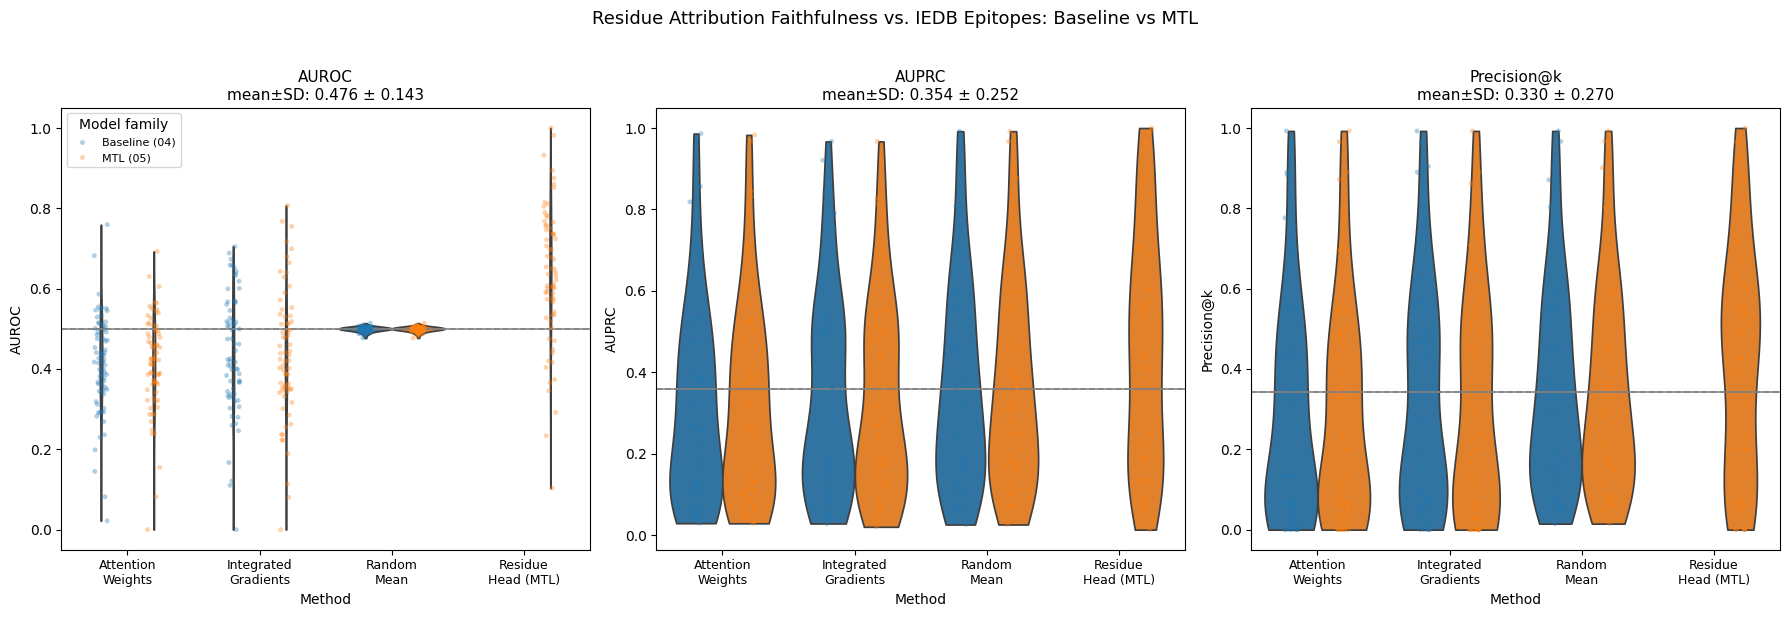

Saved plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_vs_baseline_probing_violins.png


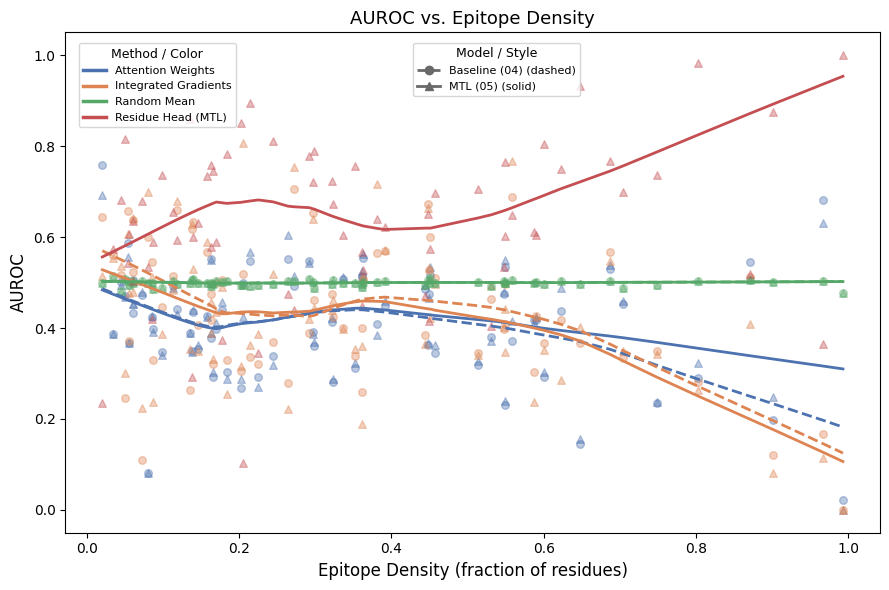

Saved plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_vs_baseline_probing_auroc_vs_density.png


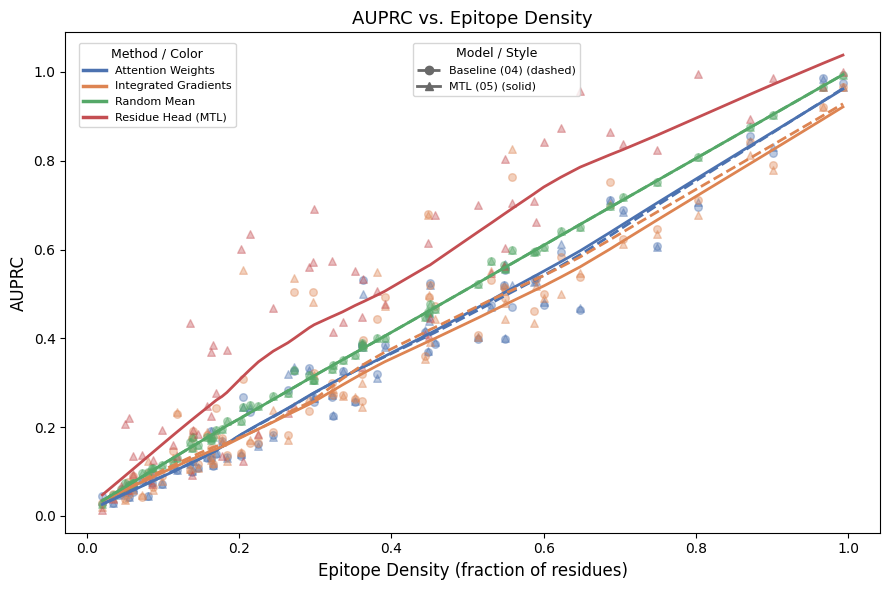

Saved plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_vs_baseline_probing_auprc_vs_density.png


In [35]:
plot_probe_violins(
    probe_outputs["combined_probe_df"],
    OUTPUT_PATHS.combined_violins_png,
)

plot_probe_density_trends(
    probe_outputs["combined_probe_df"],
    OUTPUT_PATHS.combined_auroc_density_png,
    OUTPUT_PATHS.combined_auprc_density_png,
)


In [36]:
if RUN_TARGET == "colab":
    import shutil as _shutil

    DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
    DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

    for _src, _dst_dir in [
        (OUTPUT_PATHS.checkpoint_path, DRIVE_MODELS),
        (OUTPUT_PATHS.metrics_path, DRIVE_RESULTS),
        (OUTPUT_PATHS.probe_rows_path, DRIVE_RESULTS),
        (OUTPUT_PATHS.baseline_probe_rows_path, DRIVE_RESULTS),
        (OUTPUT_PATHS.combined_probe_rows_path, DRIVE_RESULTS),
        (OUTPUT_PATHS.probe_summary_path, DRIVE_RESULTS),
        (OUTPUT_PATHS.compare_summary_path, DRIVE_RESULTS),
        (OUTPUT_PATHS.combined_violins_png, DRIVE_RESULTS),
        (OUTPUT_PATHS.combined_auroc_density_png, DRIVE_RESULTS),
        (OUTPUT_PATHS.combined_auprc_density_png, DRIVE_RESULTS),
    ]:
        if _src.exists():
            _shutil.copy2(_src, _dst_dir / _src.name)
            print(f"Copied to Drive: {_dst_dir / _src.name}")
        else:
            print(f"Skipped missing output: {_src}")
else:
    print("Local run: outputs saved to:")
    for _out_path in [
        OUTPUT_PATHS.checkpoint_path,
        OUTPUT_PATHS.metrics_path,
        OUTPUT_PATHS.probe_rows_path,
        OUTPUT_PATHS.baseline_probe_rows_path,
        OUTPUT_PATHS.combined_probe_rows_path,
        OUTPUT_PATHS.probe_summary_path,
        OUTPUT_PATHS.compare_summary_path,
        OUTPUT_PATHS.combined_violins_png,
        OUTPUT_PATHS.combined_auroc_density_png,
        OUTPUT_PATHS.combined_auprc_density_png,
    ]:
        print(f"  {_out_path}")


Local run: outputs saved to:
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/models/mtl_frozen_esm2_epitope.pt
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_baseline_metrics.json
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_probing_rows.csv
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/baseline_probing_rows.csv
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_vs_baseline_probing_rows.csv
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/mtl_probing_summary.csv
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2

## Interpretation Guide

What to inspect after a run:
- `mtl_epitope_notebook_utils.py` for the implementation details behind training, evaluation, probing, and plots.
- `results/mtl_top1_unfrozen_baseline_metrics.json` for sequence-level and flattened residue-level metrics.
- `history_df` for whether validation gains are coming from protein classification, residue supervision, or both.
- `results/mtl_top1_unfrozen_probing_summary.csv` for held-out probe scores on `positives_splitB.csv`.
- `results/mtl_top1_unfrozen_vs_baseline_summary.csv` for the delta between notebook 04 and notebook 06 probing behavior.
- `results/mtl_top1_unfrozen_vs_baseline_probing_violins.png` and the density plots for whether gains are broad or concentrated in certain epitope-density regimes.

A healthy outcome here is: protein-level classification stays stable while residue-head probing and attribution alignment improve.
